In [ ]:
!pip install bayesian-optimization
!pip install scikit-optimize
!pip install hyperopt
!pip install ConfigSpace
!pip install smac

import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bayes_opt import BayesianOptimization
from bayes_opt.acquisition import ExpectedImprovement
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from skopt import forest_minimize
from skopt.space import Real
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 kB 2.1 MB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.9/172.9 kB 1.6 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 9.2 MB/s eta 0:00:00:00:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.6 MB/s eta 0:00:00
  Created wheel for smac: filename=smac-2.4.1-py3-none-any.whl size=236299 sha256=dead0d914ff1db14aff9a8fc55199b35053ccecc13975de14a89874a7d3ac

## Patient response function and Bayesian optimzer algorithm functions.

In [3]:
import pandas as pd
import numpy as np
from bayes_opt import BayesianOptimization
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from ConfigSpace import ConfigurationSpace, Float
from smac import HyperparameterOptimizationFacade, Scenario

# Here are many different families of patients.

baseline_family = {
    'name': 'quick_rise_slow_fall',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

symmetric_family = {
    'name': 'symmetric',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'symmetric',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

slow_rise_quick_fall_family = {
    'name': 'slow_rise_quick_fall',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'slow_rise_quick_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

three_optima_family = {
    'name': '3optima',
    'num_optima': 3,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

broad_peaks_family = {
    'name': 'broad_optima',
    'num_optima': 2,
    'spread_scale': 2.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

sharp_peaks_family = {
    'name': 'sharp_optima',
    'num_optima': 2,
    'spread_scale': 0.4,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'none'
}

heteroscedastic_noise_family = {
    'name': 'heteroscedastic_noise',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'heteroscedastic',
    'unique_parameter_interaction': 'none'
}

heavy_tailed_noise_family = {
    'name': 'heavy_tailed_noise',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'heavy_tailed',
    'unique_parameter_interaction': 'none'
}

unique_parameter_interaction_family = {
    'name': 'unique_parameter_interaction',
    'num_optima': 2,
    'spread_scale': 1.0,
    'function_shape': 'quick_rise_slow_fall',
    'noise': 'normal',
    'unique_parameter_interaction': 'pulsewidth-amplitude'
}


def asymmetric_hill_peak(
    value,
    optimum,
    left_scale,
    right_scale,
    hill_n=4.0,
):
    """Return a Hill-like peak anchored at an explicit optimum."""
    if left_scale <= 0 or right_scale <= 0 or hill_n <= 0:
        raise ValueError("Scales and hill_n must be positive.")

    value = np.asarray(value, dtype=float)
    scale = np.where(value < optimum, left_scale, right_scale)
    distance = np.abs(value - optimum) / scale

    return 1.0 / (1.0 + distance**hill_n)


def generate_patient_profile(patient_seed: int, family: dict):
    """Draws one unique synthetic patient's response landscape for a given surface family, independent of any optimizer's own RNG."""
    rng = np.random.default_rng(patient_seed)

    base_optima = [(10.0 + rng.uniform(-2.0, 2.0), 500.0 + rng.uniform(-25.0, 25.0)), 
                   (25.0 + rng.uniform(-2.0, 2.0), 100.0 + rng.uniform(-25.0, 25.0))] #may need to change this later on.
    num_optima = family['num_optima']
    optima = []
    for numOfOptima in range(num_optima):
        if numOfOptima < len(base_optima):
            opt_f, opt_w = base_optima[numOfOptima]
        else:
            opt_f = rng.uniform(5.0, 50.0)
            opt_w = rng.uniform(150.0, 450.0)
        optima.append((opt_f, opt_w))

    spread_scale = family['spread_scale']

    if family['function_shape'] == 'quick_rise_slow_fall':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Asymmetric spreads: faster rise toward threshold, slower decline above it
            'amp_rise_pup': rng.uniform(0.25, 0.35) * spread_scale,
            'amp_fall_pup': rng.uniform(0.55, 0.75) * spread_scale,
            'amp_rise_hrv': rng.uniform(0.20, 0.30) * spread_scale,
            'amp_fall_hrv': rng.uniform(0.45, 0.65) * spread_scale,

            'freq_rise': rng.uniform(1.0, 2.0) * spread_scale,
            'freq_fall': rng.uniform(5.0, 6.0) * spread_scale,
            'pulse_width_rise': rng.uniform(20.0, 50.0) * spread_scale,
            'pulse_width_fall': rng.uniform(125.0, 175.0) * spread_scale,

            'optima': optima,
        }
    elif family['function_shape'] == 'symmetric':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Symmetric spreads: same rise and fall
            'amp_rise_pup': 0.25,
            'amp_fall_pup': 0.25,
            'amp_rise_hrv': 0.25,
            'amp_fall_hrv': 0.25,
            'freq_rise': 1.5,
            'freq_fall': 1.5,
            'pulse_width_rise': 35.0,
            'pulse_width_fall': 150.0,

            'optima': optima,
        }
    elif family['function_shape'] == 'slow_rise_quick_fall':
        return {
            'patient_seed': patient_seed,
            'surface_family': family['name'],
            'ideal_amp_pup': rng.normal(4.4, 0.15),
            'ideal_amp_hrv': rng.normal(4.0, 0.15),
            # Asymmetric spreads: slower rise toward threshold, faster decline above it
            'amp_rise_pup': rng.uniform(0.55, 0.75) * spread_scale,
            'amp_fall_pup': rng.uniform(0.25, 0.35) * spread_scale,
            'amp_rise_hrv': rng.uniform(0.45, 0.65) * spread_scale,
            'amp_fall_hrv': rng.uniform(0.20, 0.30) * spread_scale,

            'freq_rise': rng.uniform(5.0, 6.0) * spread_scale,
            'freq_fall': rng.uniform(1.0, 2.0) * spread_scale,
            'pulse_width_rise': rng.uniform(125.0, 175.0) * spread_scale,
            'pulse_width_fall': rng.uniform(20.0, 50.0) * spread_scale,

            'optima': optima,
        }


def run_optimization_comparison(num_simulation_trials: int, amount_of_patients: int, patient_and_machine_startSeed : int, patient_type: dict):

    search_boundaries = {
        'amplitude': (0.5, 5.0),       # mA
        'frequency': (1.0, 50.0),      # Hz
        'pulse_width': (50.0, 600.0),  # microseconds
    }
    
    all_patients_results = []  # accumulates each patient's comparison_data across the loop
    all_convergence_results = []

    for i in range(amount_of_patients):

        patient_profile = generate_patient_profile(patient_and_machine_startSeed, patient_type)
        ideal_amp_pup = patient_profile['ideal_amp_pup']
        amp_rise_pup = patient_profile['amp_rise_pup']
        amp_fall_pup = patient_profile['amp_fall_pup']
        ideal_amp_hrv = patient_profile['ideal_amp_hrv']
        amp_rise_hrv = patient_profile['amp_rise_hrv']
        amp_fall_hrv = patient_profile['amp_fall_hrv']
        freq_rise = patient_profile['freq_rise']
        freq_fall = patient_profile['freq_fall']
        pulse_width_rise = patient_profile['pulse_width_rise']
        pulse_width_fall = patient_profile['pulse_width_fall']
        optima = patient_profile['optima']
  

        def realistic_patient_curve(amplitude, frequency, pulse_width, AddNoise: bool, patient_and_machine_startSeed: int):

            rng = np.random.default_rng(patient_and_machine_startSeed)
            
            # Pupillometry Calculation (anchored asymmetric Hill peaks)
            amp_comp_pup = asymmetric_hill_peak(
                amplitude,
                ideal_amp_pup,
                amp_rise_pup,
                amp_fall_pup,
            )
            amp_comp_hrv = asymmetric_hill_peak(
                amplitude,
                ideal_amp_hrv,
                amp_rise_hrv,
                amp_fall_hrv,
            )

            pup_score = 100 * amp_comp_pup 
            hrv_score = 100 * amp_comp_hrv 
            w_pup, w_hrv = 0.5, 0.5
            amplitude_score = w_pup * pup_score + w_hrv * hrv_score

            # We calculate response based on proximity to the optimal (Freq, Width) pairs
            def get_interdependence_score(f, w, Amplitude_Scale_Factor = 1.0):
                scores = []
                if Amplitude_Scale_Factor != 1.0:
                    for (opt_f, opt_w) in optima:
                        freq_comp = asymmetric_hill_peak(
                            f,
                            opt_f,
                            freq_rise,
                            freq_fall,
                        )
                        width_comp = asymmetric_hill_peak(
                            w,
                            opt_w,
                            pulse_width_rise,
                            pulse_width_fall,
                        )
                        dist = ((freq_comp) * (width_comp)) * Amplitude_Scale_Factor
                        scores.append(dist)
                else:
                    for (opt_f, opt_w) in optima:
                        freq_comp = asymmetric_hill_peak(
                            f,
                            opt_f,
                            freq_rise,
                            freq_fall,
                        )
                        width_comp = asymmetric_hill_peak(
                            w,
                            opt_w,
                            pulse_width_rise,
                            pulse_width_fall,
                        )
                        dist = ((freq_comp) *  (width_comp))
                        scores.append(dist)

                return max(scores)

            if patient_type.get('unique_parameter_interaction') == 'pulsewidth-amplitude':
                inter_score = get_interdependence_score(frequency, pulse_width, amplitude_score/100)
            else:
                inter_score = get_interdependence_score(frequency, pulse_width)

            total_score = inter_score * amplitude_score

            #Now calculate best possible score:
            amplitude_grid = np.linspace(0.5, 5.0, 10_000)
            amp_comp_pup_grid = asymmetric_hill_peak(
                amplitude_grid,
                ideal_amp_pup,
                amp_rise_pup,
                amp_fall_pup,
            )

            amp_comp_hrv_grid = asymmetric_hill_peak(
                amplitude_grid,
                ideal_amp_hrv,
                amp_rise_hrv,
                amp_fall_hrv,
            )

            amplitude_scores = (
                0.5 * 100 * amp_comp_pup_grid + 0.5 * 100 * amp_comp_hrv_grid)

            best_amplitude_score = np.max(amplitude_scores)
            best_amplitude = amplitude_grid[np.argmax(amplitude_scores)]

            #1 assumes the best combo of frequency and pulse width, just for show.
            best_possible_score = best_amplitude_score * 1


            if not AddNoise:
                return total_score
             
            noise_type = patient_type.get('noise', 'normal')
            if noise_type == 'normal':
                noise = rng.normal(0, 2.0)  # e.g., standard deviation of 2.0
            elif noise_type == 'heteroscedastic':
                    # Noise scales with signal magnitude
                noise = rng.normal(0, 0.05 * amplitude_score)
            elif noise_type == 'heavy_tailed':
                    # Student's t-distribution
                noise = rng.standard_t(df=3) * 2.0
            else:
                noise = 0.0

            total_score += noise
        
            return total_score
        
        #Find the optimal score and parameters
        amplitude_grid = np.linspace(search_boundaries['amplitude'][0], search_boundaries['amplitude'][1], 10000)
        
        max_possible_score = -np.inf
        true_optimal_params = {}

        for (opt_f, opt_w) in optima:
            # Vectorized evaluation over the amplitude grid at the peak frequency & pulse width
            curve_scores = realistic_patient_curve(amplitude_grid, opt_f, opt_w, False, 0)
            best_idx = np.argmax(curve_scores)
            peak_score = curve_scores[best_idx]
            
            if peak_score > max_possible_score:
                max_possible_score = peak_score
                true_optimal_params = {
                    'amplitude': amplitude_grid[best_idx],
                    'frequency': opt_f,
                    'pulse_width': opt_w
                }

        method_codes = {
            "Bayesian Optimization": 1,
            "TPE Optimization": 2,
            "SMAC Optimization": 3,
            "Random Search": 4,
        }

        def make_evaluation_seed(profile_seed, query_index):
            sequence = np.random.SeedSequence(
                [int(profile_seed), int(query_index)]
            )
            return int(sequence.generate_state(1, dtype=np.uint32)[0])

        profile_seed = patient_and_machine_startSeed
        convergence_rows = []

        query_counts = {
            method: 0
            for method in method_codes
        }

        best_observed = {
            method: -np.inf
            for method in method_codes
        }

        best_noise_free = {
            method: -np.inf
            for method in method_codes
        }

        incumbent_noise_free = {
            method: np.nan
            for method in method_codes
        }

        def evaluate_and_record(method, params, evaluation_seed):
            query_index = query_counts[method] + 1
            query_counts[method] = query_index

            observed_score = realistic_patient_curve(
                params["amplitude"],
                params["frequency"],
                params["pulse_width"],
                True,
                evaluation_seed,
            )

            noise_free_score = realistic_patient_curve(
                params["amplitude"],
                params["frequency"],
                params["pulse_width"],
                False,
                evaluation_seed,
            )

            is_new_observed_best = observed_score > best_observed[method]

            best_observed[method] = max(
                best_observed[method],
                observed_score,
            )

            best_noise_free[method] = max(
                best_noise_free[method],
                noise_free_score,
            )

            if is_new_observed_best:
                incumbent_noise_free[method] = noise_free_score

            convergence_rows.append({
                "Profile ID": (
                    f"{patient_profile['surface_family']}::{profile_seed}"
                ),
                "Surface Family": patient_profile["surface_family"],
                "Profile Seed": profile_seed,
                "Iteration Budget": num_simulation_trials,
                "Method": method,
                "Query": query_index,
                "Evaluation Seed": evaluation_seed,
                "Amplitude": params["amplitude"],
                "Frequency": params["frequency"],
                "Pulse Width": params["pulse_width"],
                "Observed Score": observed_score,
                "Noise-Free Score": noise_free_score,
                "Cumulative Best Observed Score": best_observed[method],
                "Best Noise-Free Score So Far": best_noise_free[method],
                "Current Incumbent Noise-Free Score": incumbent_noise_free[method],
                "Normalized Regret So Far (%)": (
                    100
                    * (
                        max_possible_score
                        - best_noise_free[method]
                    )
                    / max_possible_score
                ),
            })

            return observed_score

        def objective_bo(amplitude, frequency, pulse_width):
            query_index = (
                query_counts["Bayesian Optimization"] + 1
            )
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            return evaluate_and_record(
                "Bayesian Optimization",
                {
                    "amplitude": amplitude,
                    "frequency": frequency,
                    "pulse_width": pulse_width,
                },
                evaluation_seed,
            )

        optimizer_multi = BayesianOptimization(
            f=objective_bo,
            pbounds=search_boundaries,
            acquisition_function=ExpectedImprovement(xi=0.01),
            random_state=patient_and_machine_startSeed,
            verbose=0
        )
        print(f"\n--- Starting Bayesian Optimization ({num_simulation_trials} iterations) ---")
        bo_start_time = time.perf_counter()
        optimizer_multi.maximize(init_points=max(1, num_simulation_trials // 10), n_iter=num_simulation_trials - max(1, num_simulation_trials // 10))

        bo_elapsed_seconds = time.perf_counter() - bo_start_time
        print(f"Bayesian Optimization completed in {bo_elapsed_seconds:.3f} seconds.")

        # --- TPE Optimization ---
        tpe_start_time = time.perf_counter()
        def objective_tpe(params):
            query_index = query_counts["TPE Optimization"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            score = evaluate_and_record(
                "TPE Optimization",
                {
                    "amplitude": params["amplitude"],
                    "frequency": params["frequency"],
                    "pulse_width": params["pulse_width"],
                },
                evaluation_seed,
            )

            return {
                "loss": -score,
                "status": STATUS_OK,
            }
        space = {
            'amplitude': hp.uniform('amplitude', search_boundaries['amplitude'][0], search_boundaries['amplitude'][1]),
            'frequency': hp.uniform('frequency', search_boundaries['frequency'][0], search_boundaries['frequency'][1]),
            'pulse_width': hp.uniform('pulse_width', search_boundaries['pulse_width'][0], search_boundaries['pulse_width'][1])
        }
        trials = Trials()
        print(f"\n--- Starting TPE Optimization ({num_simulation_trials} iterations) ---")
        fmin(fn=objective_tpe, space=space, algo=tpe.suggest, max_evals=num_simulation_trials, trials=trials, rstate=np.random.default_rng(patient_and_machine_startSeed))
        tpe_elapsed_seconds = time.perf_counter() - tpe_start_time
        print(f"TPE completed in {tpe_elapsed_seconds:.3f} seconds.")
        
        # --- SMAC Optimization ---
        smac_start_time = time.perf_counter()
        configspace = ConfigurationSpace(seed=patient_and_machine_startSeed)
        configspace.add([
            Float('amplitude', bounds=search_boundaries['amplitude']),
            Float('frequency', bounds=search_boundaries['frequency']),
            Float('pulse_width', bounds=search_boundaries['pulse_width']),
        ])
        
        def objective_smac(config, seed=None):
            query_index = query_counts["SMAC Optimization"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )
            score = evaluate_and_record(
                "SMAC Optimization",
                {
                    "amplitude": float(config["amplitude"]),
                    "frequency": float(config["frequency"]),
                    "pulse_width": float(config["pulse_width"]),
                },
                evaluation_seed,
            )

            return -score
        
        print(f"\n--- Starting SMAC Optimization ({num_simulation_trials} iterations) ---")
        scenario = Scenario(
            configspace,
            deterministic=False,
            n_trials=num_simulation_trials,
            seed=patient_and_machine_startSeed,
        )
        smac = HyperparameterOptimizationFacade(scenario, objective_smac)
        incumbent = smac.optimize()
        smac_score = -smac.runhistory.get_cost(incumbent)

        smac_elapsed_seconds = time.perf_counter() - smac_start_time
        print(f"SMAC completed in {smac_elapsed_seconds:.3f} seconds.")

        
        # --- Random Search ---
        rs_start_time = time.perf_counter()
        random_search_rng = np.random.default_rng(patient_and_machine_startSeed)
        best_random_score = -np.inf
        best_random_params = {}
        random_search_scores = []  # score at each evaluation, in order, for convergence tracking
        print(f"\n--- Starting Random Search Optimization ({num_simulation_trials} iterations) ---")
        for _ in range(num_simulation_trials):
            a, f, w = [
                random_search_rng.uniform(
                    search_boundaries[key][0],
                    search_boundaries[key][1],
                )
                for key in [
                    "amplitude",
                    "frequency",
                    "pulse_width",
                ]
            ]

            query_index = query_counts["Random Search"] + 1
            evaluation_seed = make_evaluation_seed(
                profile_seed,
                query_index,
            )

            current_score = evaluate_and_record(
                "Random Search",
                {
                    "amplitude": a,
                    "frequency": f,
                    "pulse_width": w,
                },
                evaluation_seed,
            )

            random_search_scores.append(current_score)

            if current_score > best_random_score:
                best_random_score = current_score
                best_random_params = {
                    "amplitude": a,
                    "frequency": f,
                    "pulse_width": w,
                }

        rs_elapsed_seconds = time.perf_counter() - rs_start_time
        print(f"Random Search completed in {rs_elapsed_seconds:.3f} seconds.")

        selected_scores_noise_free = [
            realistic_patient_curve(
                optimizer_multi.max['params']['amplitude'],
                optimizer_multi.max['params']['frequency'],
                optimizer_multi.max['params']['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                trials.argmin['amplitude'],
                trials.argmin['frequency'],
                trials.argmin['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                float(incumbent['amplitude']),
                float(incumbent['frequency']),
                float(incumbent['pulse_width']),
                False,
                patient_and_machine_startSeed,
            ),
            realistic_patient_curve(
                best_random_params['amplitude'],
                best_random_params['frequency'],
                best_random_params['pulse_width'],
                False,
                patient_and_machine_startSeed,
            ),
        ]

        simple_regrets = [
            max_possible_score - score
            for score in selected_scores_noise_free
        ]

        normalized_regrets = [
            regret / max_possible_score
            if max_possible_score > 0
            else np.nan
            for regret in simple_regrets
        ]

        comparison_data = {
            'Method': ['Bayesian Optimization', 'TPE Optimization', 'SMAC Optimization', 'Random Search'],
            'Surface Family': [patient_profile['surface_family']] * 4,
            'Seed': [patient_and_machine_startSeed] * 4,
            'Best Possible Score': [max_possible_score] * 4,
            'Best Computed Score': [optimizer_multi.max['target'], -trials.best_trial['result']['loss'], smac_score, best_random_score],
            'Selected Amplitude (mA)': [optimizer_multi.max['params']['amplitude'], trials.argmin['amplitude'], float(incumbent['amplitude']), best_random_params['amplitude']],
            'Selected Frequency (Hz)': [optimizer_multi.max['params']['frequency'], trials.argmin['frequency'], float(incumbent['frequency']), best_random_params['frequency']],
            'Selected Pulse Width (us)': [optimizer_multi.max['params']['pulse_width'], trials.argmin['pulse_width'], float(incumbent['pulse_width']), best_random_params['pulse_width']],
            
            'Selected Score (Noise-Free)': selected_scores_noise_free,
            'Simple Regret': simple_regrets,
            #Gives percentage regret just in case
            'Normalized Regret (%)': [
                                100 * regret
                                for regret in normalized_regrets
                            ],
            'Sec To Compute': [bo_elapsed_seconds, tpe_elapsed_seconds, smac_elapsed_seconds, rs_elapsed_seconds]
        }

        all_patients_results.append(pd.DataFrame(comparison_data))
        all_convergence_results.append(
            pd.DataFrame(convergence_rows)
        )

        patient_and_machine_startSeed += 1

    return all_patients_results, all_convergence_results

In [18]:
import tempfile

if "_original_smac_scenario" not in globals():
    _original_smac_scenario = Scenario
_smac_output_directories = []


def make_fresh_smac_scenario(configspace, **scenario_kwargs):
    temporary_directory = tempfile.TemporaryDirectory(prefix="smac3_output_")
    _smac_output_directories.append(temporary_directory)
    scenario_kwargs.setdefault("output_directory", temporary_directory.name)
    return _original_smac_scenario(configspace, **scenario_kwargs)


Scenario = make_fresh_smac_scenario

**BASELINE FAMILY PATIENTS**

In [5]:
baseline_family_test, baseline_convergence = run_optimization_comparison(
    num_simulation_trials=40,
    amount_of_patients=3,
    patient_and_machine_startSeed=10000,
    patient_type=baseline_family,
)


from IPython.display import FileLink, display

baseline_raw_data_path = "baseline_raw_data.pkl"
with open(baseline_raw_data_path, "wb") as file:
    pickle.dump(
        {
            "baseline_family_test": baseline_family_test,
            "baseline_convergence": baseline_convergence,
        },
        file,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

display(FileLink(baseline_raw_data_path))

with open("baseline_raw_data.pkl", "rb") as file:
    data = pickle.load(file)

baseline_family_test = data["baseline_family_test"]
baseline_convergence = data["baseline_convergence"]


--- Starting Bayesian Optimization (40 iterations) ---
Bayesian Optimization completed in 27.423 seconds.

--- Starting TPE Optimization (40 iterations) ---
100%|██████████| 40/40 [00:00<00:00, 179.54trial/s, best loss: -92.18433093723525] 
TPE completed in 0.231 seconds.

--- Starting SMAC Optimization (40 iterations) ---
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 30 to 10 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 10 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:523] Added config 7e5578 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config 5c0777 and rejected config 7e5578 as incumbent because it is not better than the incumbents on 2 instances: 
[INFO][abstract_intensifier.py:630] Added config 7b5ce8 and rejected config 5c0777 as incumbent because it is not better than the incumbents on 3 instances: 
[INFO][abstract_in

/content/baseline_raw_data.pkl

In [12]:
import itertools
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import FileLink, display


def export_family_results(
    family,
    family_test,
    family_convergence,
    iteration_budget=40,
    output_dir=".",
    file_prefix=None,
    n_permutations=20000,
    n_bootstrap=10000,
    random_seed=20260913,
    display_links=True,
):
    """Analyze one family's optimizer results and export its CSV outputs."""
    if isinstance(family, dict):
        family_name = family.get("name")
    else:
        family_name = str(family)

    if not isinstance(family_name, str) or not family_name.strip():
        raise ValueError("family must be a non-empty name or a dict with a 'name'.")
    if not isinstance(family_test, (list, tuple)) or not family_test:
        raise ValueError("family_test must be a non-empty list of per-profile DataFrames.")
    if not isinstance(family_convergence, (list, tuple)):
        raise ValueError("family_convergence must be a list of per-profile DataFrames.")
    if len(family_test) != len(family_convergence):
        raise ValueError("family_test and family_convergence must have the same length.")
    if not all(isinstance(frame, pd.DataFrame) for frame in family_test):
        raise TypeError("Every item in family_test must be a pandas DataFrame.")
    if not all(isinstance(frame, pd.DataFrame) for frame in family_convergence):
        raise TypeError("Every item in family_convergence must be a pandas DataFrame.")

    required_columns = {
        "Surface Family",
        "Seed",
        "Method",
        "Best Possible Score",
        "Selected Score (Noise-Free)",
    }
    missing_columns = set().union(
        *(required_columns.difference(frame.columns) for frame in family_test)
    )
    if missing_columns:
        raise ValueError(f"Missing family result columns: {sorted(missing_columns)}")

    family_results_df = pd.concat(
        [
            result.assign(
                **{
                    "Profile Index": profile_index,
                    "Profile ID": result["Surface Family"].astype(str)
                    + "::"
                    + result["Seed"].astype(str),
                    "Iteration Budget": iteration_budget,
                }
            )
            for profile_index, result in enumerate(family_test, start=1)
        ],
        ignore_index=True,
    )

    observed_families = set(family_results_df["Surface Family"].astype(str).unique())
    if observed_families != {family_name}:
        raise ValueError(
            f"family name {family_name!r} does not match result families {sorted(observed_families)}."
        )

    family_convergence_df = pd.concat(
        [
            convergence.assign(**{"Profile Index": profile_index})
            for profile_index, convergence in enumerate(family_convergence, start=1)
        ],
        ignore_index=True,
    )

    analysis_df = family_results_df.copy()
    analysis_df["Normalized Regret"] = (
        analysis_df["Best Possible Score"]
        - analysis_df["Selected Score (Noise-Free)"]
    ) / analysis_df["Best Possible Score"]

    method_order = [
        "Bayesian Optimization",
        "TPE Optimization",
        "SMAC Optimization",
        "Random Search",
    ]
    methods = [
        method
        for method in method_order
        if method in analysis_df["Method"].unique()
    ]
    if len(methods) != len(method_order):
        raise ValueError(f"Expected all four methods; found {methods}.")

    duplicate_keys = analysis_df.duplicated(
        subset=["Profile ID", "Method"],
        keep=False,
    )
    if duplicate_keys.any():
        raise ValueError(
            "Each family profile-method combination must have exactly one result."
        )

    family_wide = analysis_df.pivot(
        index="Profile ID",
        columns="Method",
        values="Normalized Regret",
    ).reindex(columns=methods).dropna()

    if len(family_wide) < 2:
        raise ValueError("At least two complete paired profiles are required.")

    def omnibus_permutation_test(wide, seed):
        values = wide.to_numpy(dtype=float)
        observed_statistic = float(np.ptp(values.mean(axis=0)))
        rng = np.random.default_rng(seed)
        permuted_statistics = np.empty(n_permutations)

        for permutation_index in range(n_permutations):
            permuted_values = np.array(
                [rng.permutation(profile_values) for profile_values in values]
            )
            permuted_statistics[permutation_index] = np.ptp(
                permuted_values.mean(axis=0)
            )

        p_value = (
            1
            + np.count_nonzero(permuted_statistics >= observed_statistic)
        ) / (n_permutations + 1)
        return observed_statistic, p_value

    def paired_sign_flip_test(first, second, seed):
        differences = np.asarray(first, dtype=float) - np.asarray(second, dtype=float)
        observed_difference = float(np.mean(differences))
        rng = np.random.default_rng(seed)
        signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(n_permutations, len(differences)),
        )
        permuted_means = np.mean(signs * differences, axis=1)
        p_value = (
            1
            + np.count_nonzero(
                np.abs(permuted_means) >= abs(observed_difference)
            )
        ) / (n_permutations + 1)
        return observed_difference, p_value

    def paired_bootstrap_ci(differences, seed):
        differences = np.asarray(differences, dtype=float)
        rng = np.random.default_rng(seed)
        indices = rng.integers(
            0,
            len(differences),
            size=(n_bootstrap, len(differences)),
        )
        bootstrap_means = differences[indices].mean(axis=1)
        return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))

    def holm_adjust(p_values):
        p_values = np.asarray(p_values, dtype=float)
        order = np.argsort(p_values)
        sorted_p_values = p_values[order]
        adjusted_sorted = np.maximum.accumulate(
            (len(sorted_p_values) - np.arange(len(sorted_p_values)))
            * sorted_p_values
        )
        adjusted = np.empty_like(adjusted_sorted)
        adjusted[order] = np.minimum(adjusted_sorted, 1.0)
        return adjusted

    friedman_statistic, friedman_p_value = stats.friedmanchisquare(
        *[family_wide[method].to_numpy() for method in methods]
    )
    omnibus_statistic, omnibus_p_value = omnibus_permutation_test(
        family_wide,
        seed=random_seed + iteration_budget,
    )
    kendalls_w = friedman_statistic / (
        len(family_wide) * (len(methods) - 1)
    )

    omnibus_df = pd.DataFrame(
        [
            {
                "Surface Family": family_name,
                "Iteration Budget": iteration_budget,
                "N Paired Profiles": len(family_wide),
                "Endpoint": "Noise-free normalized regret",
                "Friedman Statistic": friedman_statistic,
                "Friedman P Value": friedman_p_value,
                "Kendalls W": kendalls_w,
                "Permutation Range Statistic": omnibus_statistic,
                "Paired Permutation P Value": omnibus_p_value,
            }
        ]
    )

    pairwise_rows = []
    for pair_index, (method_a, method_b) in enumerate(
        itertools.combinations(methods, 2)
    ):
        differences = (
            family_wide[method_a].to_numpy()
            - family_wide[method_b].to_numpy()
        )
        mean_difference, p_value = paired_sign_flip_test(
            family_wide[method_a],
            family_wide[method_b],
            seed=random_seed + 100000 + pair_index,
        )
        ci_low, ci_high = paired_bootstrap_ci(
            differences,
            seed=random_seed + 200000 + pair_index,
        )
        difference_sd = np.std(differences, ddof=1)
        pairwise_rows.append(
            {
                "Surface Family": family_name,
                "Iteration Budget": iteration_budget,
                "Method A": method_a,
                "Method B": method_b,
                "N Paired Profiles": len(differences),
                "Mean Regret Difference (A - B)": mean_difference,
                "95% Bootstrap CI Low": ci_low,
                "95% Bootstrap CI High": ci_high,
                "Paired Effect Size dz": (
                    mean_difference / difference_sd
                    if difference_sd > 0
                    else np.nan
                ),
                "P Method A Has Lower Regret": np.mean(differences < 0),
                "P Value": p_value,
            }
        )

    pairwise_df = pd.DataFrame(pairwise_rows)
    pairwise_df["Holm Adjusted P Value"] = holm_adjust(
        pairwise_df["P Value"]
    )

    summary_df = (
        analysis_df.groupby("Method")["Normalized Regret"]
        .agg(
            N_Profiles="count",
            Mean_Regret="mean",
            SD_Regret="std",
            Median_Regret="median",
            Q25_Regret=lambda values: values.quantile(0.25),
            Q75_Regret=lambda values: values.quantile(0.75),
        )
        .reindex(methods)
        .reset_index()
    )

    safe_prefix = re.sub(
        r"[^A-Za-z0-9_-]+",
        "_",
        str(file_prefix or family_name).strip(),
    ).strip("_")
    if not safe_prefix:
        raise ValueError("file_prefix must contain at least one usable character.")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    family_title = safe_prefix.replace("_", " ").title()
    download_files = {
        f"{family_title} profile results": (
            output_dir / f"{safe_prefix}_family_results.csv",
            family_results_df,
        ),
        f"{family_title} convergence results": (
            output_dir / f"{safe_prefix}_family_convergence.csv",
            family_convergence_df,
        ),
        f"{family_title} descriptive statistics": (
            output_dir / f"{safe_prefix}_summary_statistics.csv",
            summary_df,
        ),
        f"{family_title} omnibus tests": (
            output_dir / f"{safe_prefix}_omnibus_tests.csv",
            omnibus_df,
        ),
        f"{family_title} paired post-hoc tests": (
            output_dir / f"{safe_prefix}_pairwise_tests.csv",
            pairwise_df,
        ),
    }

    for path, frame in download_files.values():
        frame.to_csv(path, index=False)

    print(
        f"Exported {family_name!r}: {len(family_results_df):,} profile-method rows, "
        f"{len(family_convergence_df):,} query rows, and "
        f"{len(download_files)} CSV files."
    )
    if display_links:
        for label, (path, _) in download_files.items():
            display(FileLink(str(path), result_html_prefix=f"{label}: "))

    return {
        "family_name": family_name,
        "results_df": family_results_df,
        "convergence_df": family_convergence_df,
        "analysis_df": analysis_df,
        "wide": family_wide,
        "summary_df": summary_df,
        "omnibus_df": omnibus_df,
        "pairwise_df": pairwise_df,
        "files": {label: str(path) for label, (path, _) in download_files.items()},
    }


def run_and_export_family(
    family,
    num_simulation_trials=40,
    amount_of_patients=40,
    patient_and_machine_startSeed=10000,
    iteration_budget=None,
    output_dir=".",
    file_prefix=None,
    **export_kwargs,
):
    """Run one family through all optimizers, analyze it, and export its CSVs."""
    family_test, family_convergence = run_optimization_comparison(
        num_simulation_trials=num_simulation_trials,
        amount_of_patients=amount_of_patients,
        patient_and_machine_startSeed=patient_and_machine_startSeed,
        patient_type=family,
    )
    outputs = export_family_results(
        family=family,
        family_test=family_test,
        family_convergence=family_convergence,
        iteration_budget=(
            num_simulation_trials
            if iteration_budget is None
            else iteration_budget
        ),
        output_dir=output_dir,
        file_prefix=file_prefix,
        **export_kwargs,
    )
    outputs["family_test"] = family_test
    outputs["family_convergence"] = family_convergence
    return outputs

In [15]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestPower


def analyze_family_results(
    family_data,
    family_convergence=None,
    *,
    family_name=None,
    iteration_budget=40,
    score_column=None,
    regret_tolerance=0.05,
    n_permutations=20000,
    n_bootstrap=10000,
    random_seed=20260913,
    display_results=True,
    plot_results=True,
):
    """Analyze one patient-response family using the reviewer's requested endpoints."""
    if n_permutations < 1 or n_bootstrap < 1:
        raise ValueError("n_permutations and n_bootstrap must both be positive.")

    if isinstance(family_data, dict):
        result_data = family_data.get("results_df")
        if result_data is None:
            result_data = family_data.get("family_test")
        if result_data is None:
            raise ValueError(
                "family_data must contain 'results_df' or 'family_test'."
            )
        if family_convergence is None:
            family_convergence = family_data.get("convergence_df")
            if family_convergence is None:
                family_convergence = family_data.get("family_convergence")
        if family_name is None:
            family_name = family_data.get("family_name")
    else:
        result_data = family_data

    if isinstance(result_data, pd.DataFrame):
        analysis_df = result_data.copy()
    elif isinstance(result_data, (list, tuple)) and result_data:
        result_frames = []
        for profile_index, result_frame in enumerate(result_data, start=1):
            if not isinstance(result_frame, pd.DataFrame):
                raise TypeError("Each family result must be a pandas DataFrame.")
            normalized_frame = result_frame.copy()
            if "Profile Index" not in normalized_frame.columns:
                normalized_frame["Profile Index"] = profile_index
            if "Iteration Budget" not in normalized_frame.columns:
                normalized_frame["Iteration Budget"] = iteration_budget
            result_frames.append(normalized_frame)
        analysis_df = pd.concat(result_frames, ignore_index=True)
    else:
        raise TypeError(
            "family_data must be a results DataFrame, a non-empty list of DataFrames, "
            "or the dictionary returned by run_and_export_family."
        )

    required_columns = {
        "Surface Family",
        "Seed",
        "Method",
        "Best Possible Score",
    }
    missing_columns = required_columns.difference(analysis_df.columns)
    if missing_columns:
        raise ValueError(f"Missing required result columns: {sorted(missing_columns)}")

    score_candidates = [
        "Selected Score (Noise-Free)",
        "Independent Reevaluation Score",
    ]
    if score_column is None:
        score_column = next(
            (
                candidate
                for candidate in score_candidates
                if candidate in analysis_df.columns
                and not analysis_df[candidate].isna().all()
            ),
            None,
        )
    if score_column is None or score_column not in analysis_df.columns:
        raise ValueError(
            "A selected noise-free or independent reevaluation score is required. "
            "The noisy maximum in 'Best Computed Score' is not an acceptable primary endpoint."
        )
    if score_column == "Best Computed Score":
        raise ValueError(
            "Best Computed Score is a noisy maximum and cannot be the primary endpoint."
        )

    analysis_df["Surface Family"] = analysis_df["Surface Family"].astype(str)
    observed_families = set(analysis_df["Surface Family"].unique())
    if family_name is None:
        if len(observed_families) != 1:
            raise ValueError(
                "family_name is required when results contain more than one family."
            )
        family_name = next(iter(observed_families))
    family_name = str(family_name)
    if observed_families != {family_name}:
        raise ValueError(
            f"family_name {family_name!r} does not match result families "
            f"{sorted(observed_families)}."
        )

    if "Iteration Budget" not in analysis_df.columns:
        analysis_df["Iteration Budget"] = iteration_budget
    analysis_df["Iteration Budget"] = pd.to_numeric(
        analysis_df["Iteration Budget"], errors="coerce"
    )
    if analysis_df["Iteration Budget"].isna().any():
        raise ValueError("Iteration Budget must be numeric for every result row.")
    analysis_df["Iteration Budget"] = analysis_df["Iteration Budget"].astype(int)

    if "Profile ID" not in analysis_df.columns:
        analysis_df["Profile ID"] = (
            analysis_df["Surface Family"]
            + "::"
            + analysis_df["Seed"].astype(str)
        )
    else:
        analysis_df["Profile ID"] = analysis_df["Profile ID"].astype(str)

    numeric_columns = ["Best Possible Score", score_column]
    if "Sec To Compute" in analysis_df.columns:
        numeric_columns.append("Sec To Compute")
    for column in numeric_columns:
        analysis_df[column] = pd.to_numeric(analysis_df[column], errors="coerce")
    if analysis_df[numeric_columns].isna().any().any():
        raise ValueError("Required numeric result columns contain missing or invalid values.")
    if not np.isfinite(analysis_df[numeric_columns].to_numpy(dtype=float)).all():
        raise ValueError("Required numeric result columns contain non-finite values.")
    if (analysis_df["Best Possible Score"] <= 0).any():
        raise ValueError("Best Possible Score must be positive to calculate regret.")

    analysis_df["Simple Regret"] = (
        analysis_df["Best Possible Score"] - analysis_df[score_column]
    )
    analysis_df["Normalized Score Regret"] = (
        analysis_df["Simple Regret"] / analysis_df["Best Possible Score"]
    )

    method_order = [
        "Bayesian Optimization",
        "TPE Optimization",
        "SMAC Optimization",
        "Random Search",
    ]
    analysis_df["Method"] = analysis_df["Method"].astype(str)
    methods = [
        method
        for method in method_order
        if method in analysis_df["Method"].unique()
    ]
    missing_methods = [method for method in method_order if method not in methods]
    if missing_methods:
        raise ValueError(f"Expected all four methods; missing {missing_methods}.")

    def paired_wide(frame, budget):
        budget_frame = frame[frame["Iteration Budget"] == budget].copy()
        duplicate_keys = budget_frame.duplicated(
            subset=["Profile ID", "Method"],
            keep=False,
        )
        if duplicate_keys.any():
            raise ValueError(
                "Each profile-method-budget combination must have exactly one result."
            )
        return budget_frame.pivot(
            index="Profile ID",
            columns="Method",
            values=score_column,
        ).reindex(columns=methods).dropna()

    def paired_sign_flip_test(first, second, seed):
        differences = np.asarray(first, dtype=float) - np.asarray(second, dtype=float)
        observed_difference = float(np.mean(differences))
        rng = np.random.default_rng(seed)
        signs = rng.choice(
            np.array([-1.0, 1.0]),
            size=(n_permutations, len(differences)),
        )
        permuted_means = np.mean(signs * differences, axis=1)
        p_value = (
            1
            + np.count_nonzero(np.abs(permuted_means) >= abs(observed_difference))
        ) / (n_permutations + 1)
        return differences, observed_difference, p_value

    def paired_bootstrap_ci(differences, seed):
        differences = np.asarray(differences, dtype=float)
        rng = np.random.default_rng(seed)
        indices = rng.integers(
            0,
            len(differences),
            size=(n_bootstrap, len(differences)),
        )
        bootstrap_means = differences[indices].mean(axis=1)
        return tuple(np.quantile(bootstrap_means, [0.025, 0.975]))

    def omnibus_permutation_test(wide, seed):
        values = wide.to_numpy(dtype=float)
        observed_statistic = float(np.ptp(values.mean(axis=0)))
        rng = np.random.default_rng(seed)
        permuted_statistics = np.empty(n_permutations)
        for permutation_index in range(n_permutations):
            permuted_values = np.array(
                [rng.permutation(profile_values) for profile_values in values]
            )
            permuted_statistics[permutation_index] = np.ptp(
                permuted_values.mean(axis=0)
            )
        p_value = (
            1
            + np.count_nonzero(permuted_statistics >= observed_statistic)
        ) / (n_permutations + 1)
        return observed_statistic, p_value

    def welch_anova(wide):
        group_values = [wide[method].to_numpy(dtype=float) for method in methods]
        sample_sizes = np.array([len(values) for values in group_values], dtype=float)
        variances = np.array(
            [np.var(values, ddof=1) for values in group_values],
            dtype=float,
        )
        variances = np.maximum(variances, np.finfo(float).eps)
        weights = sample_sizes / variances
        total_weight = weights.sum()
        group_means = np.array([np.mean(values) for values in group_values])
        weighted_mean = np.sum(weights * group_means) / total_weight
        correction_component = np.sum(
            ((1.0 - weights / total_weight) ** 2) / (sample_sizes - 1.0)
        )
        denominator = 1.0 + (
            2.0
            * (len(methods) - 2)
            / (len(methods) ** 2 - 1)
            * correction_component
        )
        statistic = (
            np.sum(weights * (group_means - weighted_mean) ** 2)
            / (len(methods) - 1)
            / denominator
        )
        degrees_of_freedom_2 = (
            (len(methods) ** 2 - 1) / (3.0 * correction_component)
            if correction_component > 0
            else np.inf
        )
        p_value = stats.f.sf(statistic, len(methods) - 1, degrees_of_freedom_2)
        return {
            "Welch F Statistic": statistic,
            "Welch DF 1": len(methods) - 1,
            "Welch DF 2": degrees_of_freedom_2,
            "Welch P Value": p_value,
        }

    def build_games_howell_rows(wide, budget):
        group_statistics = {}
        for method in methods:
            values = wide[method].to_numpy(dtype=float)
            group_statistics[method] = {
                "mean": np.mean(values),
                "variance": max(np.var(values, ddof=1), np.finfo(float).eps),
                "size": len(values),
            }

        rows = []
        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            statistics_a = group_statistics[method_a]
            statistics_b = group_statistics[method_b]
            variance_a = statistics_a["variance"] / statistics_a["size"]
            variance_b = statistics_b["variance"] / statistics_b["size"]
            variance_sum = variance_a + variance_b
            standard_error = np.sqrt(variance_sum / 2.0)
            mean_difference = statistics_a["mean"] - statistics_b["mean"]
            degrees_of_freedom = variance_sum**2 / (
                variance_a**2 / (statistics_a["size"] - 1)
                + variance_b**2 / (statistics_b["size"] - 1)
            )
            studentized_range_statistic = (
                abs(mean_difference) / standard_error
            )
            try:
                p_value = float(
                    stats.studentized_range.sf(
                        studentized_range_statistic * np.sqrt(2.0),
                        len(methods),
                        degrees_of_freedom,
                    )
                )
            except AttributeError:
                from statsmodels.stats.libqsturng import psturng

                p_value = float(
                    np.asarray(
                        psturng(
                            studentized_range_statistic * np.sqrt(2.0),
                            len(methods),
                            degrees_of_freedom,
                        )
                    ).reshape(-1)[0]
                )
            rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Profiles": len(wide),
                    "Mean Score Difference (A - B)": mean_difference,
                    "Games-Howell Studentized Range": studentized_range_statistic,
                    "Games-Howell DF": degrees_of_freedom,
                    "Games-Howell P Value": p_value,
                    "Pair Index": pair_index,
                }
            )
        return rows

    budgets = sorted(analysis_df["Iteration Budget"].unique())
    paired_scores = {}
    summary_rows = []
    omnibus_rows = []
    pairwise_rows = []
    games_howell_results = []
    power_rows = []
    skipped_budget_rows = []

    for budget in budgets:
        wide = paired_wide(analysis_df, budget)
        if len(wide) < 2:
            skipped_budget_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Complete Paired Profiles": len(wide),
                    "Reason": "At least two complete paired profiles are required.",
                }
            )
            continue

        paired_scores[budget] = wide
        permutation_statistic, permutation_p_value = omnibus_permutation_test(
            wide,
            seed=random_seed + int(budget),
        )
        friedman_statistic, friedman_p_value = stats.friedmanchisquare(
            *[wide[method].to_numpy() for method in methods]
        )
        omnibus_rows.append(
            {
                "Iteration Budget": budget,
                "N Paired Profiles": len(wide),
                "Endpoint": score_column,
                "Paired Permutation Range Statistic": permutation_statistic,
                "Paired Permutation P Value": permutation_p_value,
                "Friedman Statistic": friedman_statistic,
                "Friedman P Value": friedman_p_value,
                **welch_anova(wide),
            }
        )

        budget_frame = analysis_df[
            (analysis_df["Iteration Budget"] == budget)
            & analysis_df["Profile ID"].isin(wide.index)
        ]
        for method in methods:
            method_values = wide[method]
            method_rows = budget_frame[budget_frame["Method"] == method]
            summary_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method": method,
                    "N Profiles": len(method_values),
                    "Mean Score": method_values.mean(),
                    "SD Score": method_values.std(ddof=1),
                    "Median Score": method_values.median(),
                    "IQR Score": method_values.quantile(0.75)
                    - method_values.quantile(0.25),
                    "Mean Simple Regret": method_rows["Simple Regret"].mean(),
                    "Median Simple Regret": method_rows["Simple Regret"].median(),
                    "P Regret <= Tolerance": (
                        method_rows["Normalized Score Regret"] <= regret_tolerance
                    ).mean(),
                }
            )

        for pair_index, (method_a, method_b) in enumerate(
            itertools.combinations(methods, 2)
        ):
            differences, mean_difference, p_value = paired_sign_flip_test(
                wide[method_a],
                wide[method_b],
                seed=random_seed + 100000 + int(budget) * 100 + pair_index,
            )
            ci_low, ci_high = paired_bootstrap_ci(
                differences,
                seed=random_seed + 200000 + int(budget) * 100 + pair_index,
            )
            difference_sd = np.std(differences, ddof=1)
            pairwise_rows.append(
                {
                    "Iteration Budget": budget,
                    "Method A": method_a,
                    "Method B": method_b,
                    "N Paired Profiles": len(differences),
                    "Mean Score Difference (A - B)": mean_difference,
                    "95% Bootstrap CI Low": ci_low,
                    "95% Bootstrap CI High": ci_high,
                    "Paired Effect Size dz": (
                        mean_difference / difference_sd
                        if difference_sd > 0
                        else np.nan
                    ),
                    "P A Better Than B": np.mean(differences > 0),
                    "Paired Sign-Flip P Value": p_value,
                }
            )

        games_howell_results.extend(build_games_howell_rows(wide, budget))
        for expected_effect_size in (0.2, 0.5, 0.8):
            power_rows.append(
                {
                    "Iteration Budget": budget,
                    "N Paired Profiles": len(wide),
                    "Assumed Paired Effect Size dz": expected_effect_size,
                    "Alpha After Six Pairwise Comparisons": 0.05 / 6,
                    "Prospective Power": TTestPower().power(
                        effect_size=expected_effect_size,
                        nobs=len(wide),
                        alpha=0.05 / 6,
                        alternative="two-sided",
                    ),
                }
            )

    if not paired_scores:
        raise ValueError(
            "No iteration budget has at least two complete paired profiles."
        )

    summary_df = pd.DataFrame(summary_rows)
    omnibus_df = pd.DataFrame(omnibus_rows)
    pairwise_df = pd.DataFrame(pairwise_rows)
    games_howell_df = pd.DataFrame(games_howell_results)
    power_df = pd.DataFrame(power_rows)
    skipped_budgets_df = pd.DataFrame(skipped_budget_rows)

    if not pairwise_df.empty:
        pairwise_df["Holm Adjusted P Value"] = np.nan
        for budget in pairwise_df["Iteration Budget"].unique():
            budget_mask = pairwise_df["Iteration Budget"] == budget
            pairwise_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                pairwise_df.loc[budget_mask, "Paired Sign-Flip P Value"],
                method="holm",
            )[1]

    if not games_howell_df.empty:
        games_howell_df["Holm Adjusted P Value"] = np.nan
        for budget in games_howell_df["Iteration Budget"].unique():
            budget_mask = games_howell_df["Iteration Budget"] == budget
            games_howell_df.loc[budget_mask, "Holm Adjusted P Value"] = multipletests(
                games_howell_df.loc[budget_mask, "Games-Howell P Value"],
                method="holm",
            )[1]

    if "Sec To Compute" in analysis_df.columns:
        cost_df = (
            analysis_df.groupby(["Iteration Budget", "Method"])["Sec To Compute"]
            .agg(
                N_Profiles="count",
                Mean_Seconds="mean",
                SD_Seconds="std",
                Median_Seconds="median",
            )
            .reindex(
                pd.MultiIndex.from_product(
                    [budgets, methods],
                    names=["Iteration Budget", "Method"],
                )
            )
            .reset_index()
        )
    else:
        cost_df = pd.DataFrame(
            columns=[
                "Iteration Budget",
                "Method",
                "N_Profiles",
                "Mean_Seconds",
                "SD_Seconds",
                "Median_Seconds",
            ]
        )

    if family_convergence is None:
        convergence_df = pd.DataFrame()
    elif isinstance(family_convergence, pd.DataFrame):
        convergence_df = family_convergence.copy()
    elif isinstance(family_convergence, (list, tuple)):
        if not all(isinstance(frame, pd.DataFrame) for frame in family_convergence):
            raise TypeError("Each convergence result must be a pandas DataFrame.")
        convergence_df = pd.concat(family_convergence, ignore_index=True)
    else:
        raise TypeError(
            "family_convergence must be a DataFrame, a list of DataFrames, or None."
        )

    trajectory_score_column = None
    trajectory_summary_df = pd.DataFrame()
    common_random_number_df = pd.DataFrame()
    if not convergence_df.empty:
        if "Surface Family" not in convergence_df.columns:
            convergence_df["Surface Family"] = family_name
        if "Profile ID" not in convergence_df.columns:
            profile_seed_column = (
                "Profile Seed" if "Profile Seed" in convergence_df.columns else "Seed"
            )
            if profile_seed_column in convergence_df.columns:
                convergence_df["Profile ID"] = (
                    convergence_df["Surface Family"].astype(str)
                    + "::"
                    + convergence_df[profile_seed_column].astype(str)
                )
        if "Iteration Budget" not in convergence_df.columns:
            convergence_df["Iteration Budget"] = iteration_budget
        trajectory_score_column = next(
            (
                candidate
                for candidate in [
                    "Current Incumbent Noise-Free Score",
                    "Best Noise-Free Score So Far",
                ]
                if candidate in convergence_df.columns
            ),
            None,
        )
        if trajectory_score_column is not None:
            trajectory_summary_df = (
                convergence_df.groupby(
                    [
                        "Surface Family",
                        "Method",
                        "Iteration Budget",
                        "Query",
                    ]
                )[trajectory_score_column]
                .agg(
                    Median="median",
                    Q25=lambda values: values.quantile(0.25),
                    Q75=lambda values: values.quantile(0.75),
                )
                .reset_index()
            )
        if {
            "Profile ID",
            "Iteration Budget",
            "Query",
            "Method",
            "Evaluation Seed",
        }.issubset(convergence_df.columns):
            common_random_number_df = (
                convergence_df.groupby(
                    ["Profile ID", "Iteration Budget", "Query"]
                )
                .agg(
                    N_Methods=("Method", "nunique"),
                    N_Evaluation_Seeds=("Evaluation Seed", "nunique"),
                )
                .reset_index()
            )
            common_random_number_df["Uses Common Random Number"] = (
                (common_random_number_df["N_Methods"] == len(methods))
                & (common_random_number_df["N_Evaluation_Seeds"] == 1)
            )

    figures = {}
    if plot_results:
        score_budgets = sorted(paired_scores)
        score_figure, score_axes = plt.subplots(
            1,
            len(score_budgets),
            figsize=(6 * len(score_budgets), 5),
            squeeze=False,
        )
        for axis, budget in zip(score_axes.ravel(), score_budgets):
            wide = paired_scores[budget]
            axis.boxplot(
                [wide[method].to_numpy() for method in methods],
                labels=methods,
                patch_artist=True,
            )
            axis.set_title(f"{family_name}: selected endpoint, {budget} queries")
            axis.set_ylabel(score_column)
            axis.tick_params(axis="x", labelrotation=25)
            axis.grid(axis="y", alpha=0.25)
        score_figure.tight_layout()
        figures["selected_score_distribution"] = score_figure
        plt.show()

        if not cost_df.empty:
            cost_figure, cost_axis = plt.subplots(figsize=(8, 5))
            cost_pivot = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="Mean_Seconds",
            ).reindex(methods)
            cost_error = cost_df.pivot(
                index="Method",
                columns="Iteration Budget",
                values="SD_Seconds",
            ).reindex(methods)
            cost_pivot.plot(kind="bar", yerr=cost_error, ax=cost_axis, capsize=4)
            cost_axis.set_title(f"{family_name}: computational cost")
            cost_axis.set_ylabel("Seconds per profile")
            cost_axis.grid(axis="y", alpha=0.25)
            cost_figure.tight_layout()
            figures["computational_cost"] = cost_figure
            plt.show()

        if not trajectory_summary_df.empty:
            trajectory_budgets = sorted(
                trajectory_summary_df["Iteration Budget"].unique()
            )
            trajectory_figure, trajectory_axes = plt.subplots(
                1,
                len(trajectory_budgets),
                figsize=(7 * len(trajectory_budgets), 5),
                squeeze=False,
            )
            for axis, budget in zip(trajectory_axes.ravel(), trajectory_budgets):
                budget_trajectory = trajectory_summary_df[
                    trajectory_summary_df["Iteration Budget"] == budget
                ]
                for method, method_data in budget_trajectory.groupby("Method"):
                    method_data = method_data.sort_values("Query")
                    query_values = method_data["Query"].to_numpy()
                    median_values = method_data["Median"].to_numpy()
                    axis.plot(query_values, median_values, label=method)
                    axis.fill_between(
                        query_values,
                        method_data["Q25"].to_numpy(),
                        method_data["Q75"].to_numpy(),
                        alpha=0.15,
                    )
                axis.set_title(f"{family_name}: convergence, {budget} queries")
                axis.set_xlabel("Query")
                axis.set_ylabel(trajectory_score_column)
                axis.grid(alpha=0.25)
            trajectory_figure.legend(loc="lower center", ncol=2)
            trajectory_figure.tight_layout(rect=(0, 0.08, 1, 1))
            figures["convergence"] = trajectory_figure
            plt.show()

    if display_results:
        print(
            f"Primary endpoint: {score_column}. "
            "The noisy observed maximum is excluded from the primary analysis."
        )
        print("\n--- Descriptive statistics, regret, and tolerance probability ---")
        display(summary_df)
        print("\n--- Paired omnibus tests ---")
        display(omnibus_df)
        print("\n--- Paired sign-flip tests with Holm correction ---")
        display(pairwise_df)
        print("\n--- Welch/Games-Howell heteroscedastic sensitivity analysis ---")
        display(games_howell_df)
        print("\n--- Prospective power calculation ---")
        display(power_df)
        print("\n--- Computational cost ---")
        display(cost_df)
        if not common_random_number_df.empty:
            print("\n--- Common-random-number audit ---")
            display(common_random_number_df)
        if not trajectory_summary_df.empty:
            print("\n--- Convergence trajectory summary ---")
            display(trajectory_summary_df)
        if not skipped_budgets_df.empty:
            print("\n--- Budgets omitted from inferential tests ---")
            display(skipped_budgets_df)

    return {
        "family_name": family_name,
        "score_column": score_column,
        "regret_tolerance": regret_tolerance,
        "analysis_df": analysis_df,
        "paired_scores": paired_scores,
        "summary_df": summary_df,
        "omnibus_df": omnibus_df,
        "pairwise_df": pairwise_df,
        "games_howell_df": games_howell_df,
        "power_df": power_df,
        "cost_df": cost_df,
        "convergence_df": convergence_df,
        "trajectory_summary_df": trajectory_summary_df,
        "common_random_number_df": common_random_number_df,
        "skipped_budgets_df": skipped_budgets_df,
        "figures": figures,
    }


--- Starting Bayesian Optimization (3 iterations) ---
Bayesian Optimization completed in 0.587 seconds.

--- Starting TPE Optimization (3 iterations) ---
  0%|          | 0/3 [00:00<?, ?trial/s, best loss=?][INFO][tpe.py:860] build_posterior_wrapper took 0.001413 seconds
[INFO][tpe.py:895] TPE using 0 trials
[INFO][tpe.py:860] build_posterior_wrapper took 0.001323 seconds
[INFO][tpe.py:895] TPE using 1/1 trials with best loss 1.753047
[INFO][tpe.py:860] build_posterior_wrapper took 0.001338 seconds
[INFO][tpe.py:895] TPE using 2/2 trials with best loss -0.266689
100%|██████████| 3/3 [00:00<00:00, 63.51trial/s, best loss: -0.2666893974433806]
TPE completed in 0.057 seconds.

--- Starting SMAC Optimization (3 iterations) ---
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 30 to 1 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:523] Ad

/tmp/ipykernel_858/2786601537.py:598: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


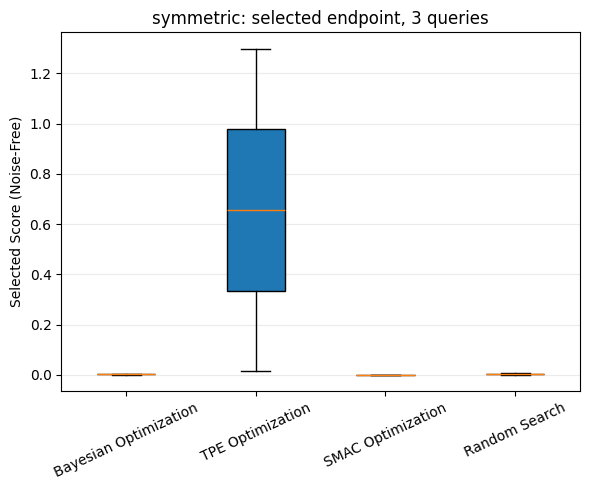

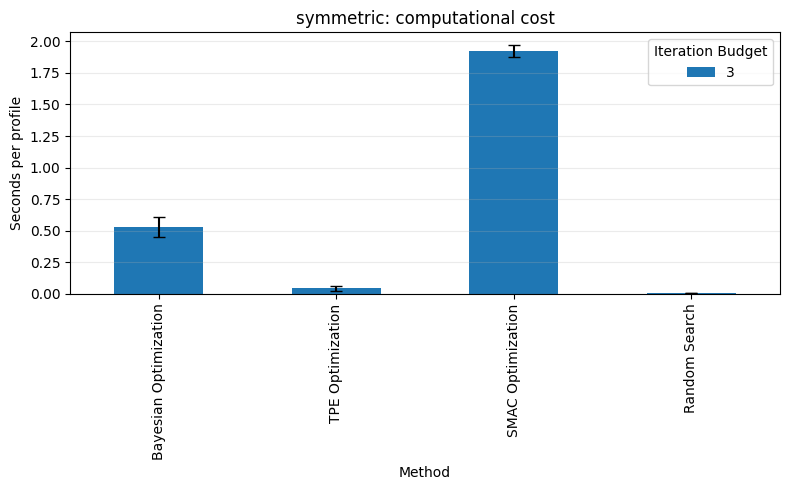

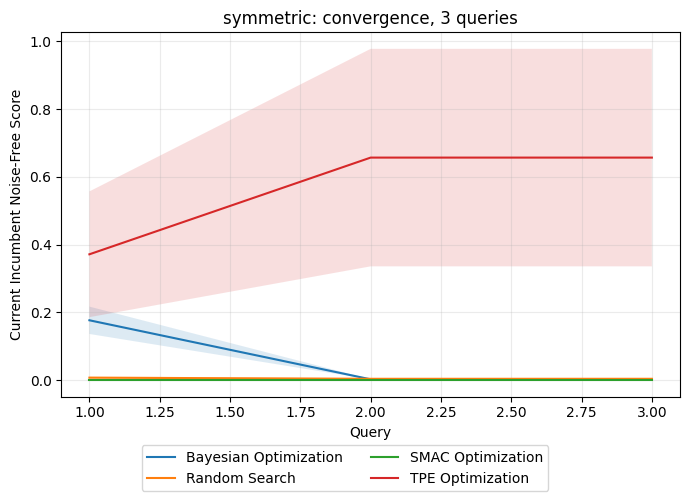

Primary endpoint: Selected Score (Noise-Free). The noisy observed maximum is excluded from the primary analysis.

--- Descriptive statistics, regret, and tolerance probability ---


,Iteration Budget,Method,N Profiles,Mean Score,SD Score,Median Score,IQR Score,Mean Simple Regret,Median Simple Regret,P Regret <= Tolerance
0,3,Bayesian Optimization,2,0.002286,0.000688,0.002286,0.000486,88.570272,88.570272,0.0
1,3,TPE Optimization,2,0.656772,0.907958,0.656772,0.642023,87.915786,87.915786,0.0
2,3,SMAC Optimization,2,0.000008,0.000007,0.000008,0.000005,88.572550,88.572550,0.0
3,3,Random Search,2,0.003869,0.005446,0.003869,0.003851,88.568689,88.568689,0.0



--- Paired omnibus tests ---


,Iteration Budget,N Paired Profiles,Endpoint,Paired Permutation Range Statistic,Paired Permutation P Value,Friedman Statistic,Friedman P Value,Welch F Statistic,Welch DF 1,Welch DF 2,Welch P Value
0,3,2,Selected Score (Noise-Free),0.656764,0.085596,5.4,0.144744,4.443777,3,1.666777,0.223



--- Paired sign-flip tests with Holm correction ---


...


--- Common-random-number audit ---


,Profile ID,Iteration Budget,Query,N_Methods,N_Evaluation_Seeds,Uses Common Random Number
0,symmetric::10000,3,1,4,1,True
1,symmetric::10000,3,2,4,1,True
2,symmetric::10000,3,3,4,1,True
3,symmetric::10001,3,1,4,1,True
4,symmetric::10001,3,2,4,1,True
5,symmetric::10001,3,3,4,1,True



--- Convergence trajectory summary ---


,Surface Family,Method,Iteration Budget,Query,Median,Q25,Q75
0,symmetric,Bayesian Optimization,3,1,0.176583,0.136166,0.216999
1,symmetric,Bayesian Optimization,3,2,0.002286,0.002043,0.002529
2,symmetric,Bayesian Optimization,3,3,0.002286,0.002043,0.002529
3,symmetric,Random Search,3,1,0.007207,0.003804,0.010610
4,symmetric,Random Search,3,2,0.003869,0.001944,0.005794
5,symmetric,Random Search,3,3,0.003869,0.001944,0.005794
6,symmetric,SMAC Optimization,3,1,0.000008,0.000006,0.000011
7,symmetric,SMAC Optimization,3,2,0.000008,0.000006,0.000011
8,symmetric,SMAC Optimization,3,3,0.000008,0.000006,0.000011
9,symmetric,TPE Optimization,3,1,0.371337,0.185753,0.556921


,Iteration Budget,Method,N Profiles,Mean Score,SD Score,Median Score,IQR Score,Mean Simple Regret,Median Simple Regret,P Regret <= Tolerance
0,3,Bayesian Optimization,2,0.002286,0.000688,0.002286,0.000486,88.570272,88.570272,0.0
1,3,TPE Optimization,2,0.656772,0.907958,0.656772,0.642023,87.915786,87.915786,0.0
2,3,SMAC Optimization,2,0.000008,0.000007,0.000008,0.000005,88.572550,88.572550,0.0
3,3,Random Search,2,0.003869,0.005446,0.003869,0.003851,88.568689,88.568689,0.0


In [19]:
# Generic usage: replace symmetric_family with any family configuration.
family_outputs = run_and_export_family(
    family=symmetric_family,
    num_simulation_trials=3,
    amount_of_patients=2,
    patient_and_machine_startSeed=10000,
    display_links=False,
)

family_statistics = analyze_family_results(family_outputs)
family_statistics["summary_df"]

In [ ]:
final_comparison_df = pd.concat(
    baseline_family_test,
    three_optima_family_test,
    broad_peaks_family_test,
    sharp_peaks_family_test,
    heteroscedastic_family_test,
    heavy_tailed_noise_family_test,
    unique_parameter_interaction_family_test,
    slow_rise_quick_fall_test,
    ignore_index=True,
)

convergence_df = pd.concat(
    [
        *baseline_convergence,
        *three_optima_convergence,
        *broad_peaks_convergence,
        *sharp_peaks_convergence,
        *heteroscedastic_convergence,
        *heavy_tailed_noise_convergence,
        *unique_parameter_interaction_convergence,
    ],
    ignore_index=True,
)

print("\n--- Combined Optimization Comparison Results ---")
display(final_comparison_df.head())
final_comparison_df.to_csv('combined_optimization_results.csv', index=False)

In [ ]:
import matplotlib.pyplot as plt

trajectory_summary = (
    convergence_df
    .groupby(
        [
            "Surface Family",
            "Method",
            "Iteration Budget",
            "Query",
        ]
    )["Current Incumbent Noise-Free Score"]
    .agg(
        Median="median",
        Q25=lambda values: values.quantile(0.25),
        Q75=lambda values: values.quantile(0.75),
    )
    .reset_index()
)

families = trajectory_summary["Surface Family"].unique()
n_columns = 2
n_rows = int(np.ceil(len(families) / n_columns))

figure, axes = plt.subplots(
    n_rows,
    n_columns,
    figsize=(14, 4 * n_rows),
    squeeze=False,
)
axes = axes.ravel()

for axis, family in zip(axes, families):
    family_data = trajectory_summary[
        trajectory_summary["Surface Family"] == family
    ]

    for method, method_data in family_data.groupby("Method"):
        method_data = method_data.sort_values("Query")
        queries = method_data["Query"].to_numpy()

        axis.plot(
            queries,
            method_data["Median"].to_numpy(),
            label=method,
        )
        axis.fill_between(
            queries,
            method_data["Q25"].to_numpy(),
            method_data["Q75"].to_numpy(),
            alpha=0.15,
        )

    axis.set_title(family)
    axis.set_xlabel("Query")
    axis.set_ylabel("Current Incumbent Noise-Free Score")
    axis.grid(alpha=0.25)

for axis in axes[len(families):]:
    axis.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="lower center", ncol=2)
figure.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

convergence_df.to_csv(
    "optimization_convergence_results.csv",
    index=False,
)

## Statistics about Optimization Methods
